<a href="https://colab.research.google.com/github/billalsohail/ML4MC/blob/main/Coulomb_matrix_representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
#Load modules and data

# ! pip install dscribe
import numpy as np
import math, random
import matplotlib.pyplot as plt
import pandas as pd
import json
import seaborn as sns
from scipy.sparse import load_npz
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import GridSearchCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score
from dscribe.descriptors import CoulombMatrix 
from ase import *
from ase.build import molecule
from ase.io import read, write
import io
df = pd.read_json('/content/drive/MyDrive/ColabNotebooks/Data/df_5k.json', orient='split')

In [29]:
col_names = list(df.columns)
print(col_names)
df.head(3)
print(df.shape[0])

['refcode_csd', 'canonical_smiles', 'inchi', 'number_of_atoms', 'xyz_pbe_relaxed', 'energies_occ_pbe', 'energies_occ_pbe0_vac_tier2', 'energies_occ_pbe0_water', 'energies_occ_pbe0_vac_tzvp', 'energies_occ_pbe0_vac_qzvp', 'energies_occ_gw_tzvp', 'energies_occ_gw_qzvp', 'cbs_occ_gw', 'energies_unocc_pbe', 'energies_unocc_pbe0_vac_tier2', 'energies_unocc_pbe0_water', 'energies_unocc_pbe0_vac_tzvp', 'energies_unocc_pbe0_vac_qzvp', 'energies_unocc_gw_tzvp', 'energies_unocc_gw_qzvp', 'cbs_unocc_gw', 'total_energy_pbe', 'total_energy_pbe0_vac_tier2', 'total_energy_pbe0_water', 'total_energy_pbe0_vac_tzvp', 'total_energy_pbe0_vac_qzvp', 'hirshfeld_pbe', 'hirshfeld_pbe0_vac_tier2', 'hirshfeld_pbe0_water']
5239


In [51]:

#Lets look at a random molecule represented with a Coulomb matrix 
y = df['xyz_pbe_relaxed'].shape[0]
# print(df['xyz_pbe_relaxed'])
print(y)

rand_mol = random.randint(0, y)
print(df['xyz_pbe_relaxed'].iloc[rand_mol])
mol_of_choice = df['xyz_pbe_relaxed'].iloc[rand_mol]


5239
23

N 13.04543409 14.24062842 19.94555974 
O 12.47906511 15.29589030 20.23630944 
O 14.03682384 14.14641411 19.21993037 
C 10.82774155 11.89258766 21.88500516 
C 11.45849028 10.66765007 21.56778452 
C 12.58237466 10.60984680 20.73933429 
H 13.03434701 9.64411994 20.52294468 
C 13.11310449 11.77421651 20.20055142 
H 13.98618606 11.75931551 19.55332076 
C 12.49440935 12.98687319 20.51033803 
C 11.38127126 13.05923836 21.32892527 
H 10.93230266 14.02528675 21.54290320 
Cl 10.85145266 9.16943469 22.20482800 
N 9.10123363 13.09492611 23.02145799 
N 8.02770992 13.09780016 23.81887818 
N 7.90082350 15.38697902 23.63513173 
S 6.04222200 14.19175952 25.16035582 
C 9.65827038 11.95758069 22.74643735 
H 9.26637131 11.01656778 23.15290476 
C 7.37203233 14.26717757 24.16365992 
H 7.63218436 12.24139753 24.21689764 
H 8.71684341 15.33137854 23.03452991 
H 7.46432621 16.27140711 23.85029569 



In [96]:
def xyz_to_atoms(xyz):
    f = io.StringIO()
    f.write(xyz)
    f.seek(0)  # had to add this in otherwise wont return to start of file once read in
    return read(f, format='xyz')

df['atoms'] = df['xyz_pbe_relaxed'].apply(xyz_to_atoms)
cm_desc = CoulombMatrix(n_atoms_max=23, permutation='none')
mol = df['atoms'].iloc[rand_mol]

print("answer:", isinstance(mol, Atoms))

matrix = cm_desc.create(mol)
print(matrix.shape)
shape = (23, 23)
mat = matrix.reshape(shape)
print(mat.shape)
# df['atoms'].head(5)

answer: True
(529,)
(23, 23)


<Figure size 432x288 with 0 Axes>

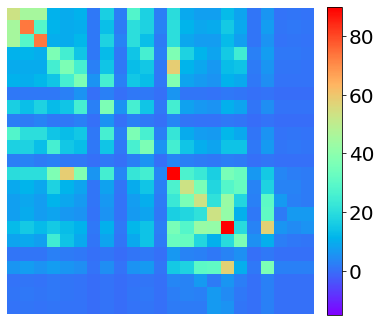

In [98]:
shape = (23, 23)
mat = matrix.reshape(shape)

plt.figure()
plt.figure(figsize = (6,6))
plt.imshow(mat, origin="upper", cmap='rainbow', vmin=-15, vmax=90, interpolation='nearest')
plt.colorbar(fraction=0.046, pad=0.04).ax.tick_params(labelsize=20)
plt.axis('off')
plt.show()